In [8]:
pip install kagglehub pandas numpy scikit-learn nltk xgboost openpyxl

In [9]:
import os
import glob
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle Hub API
import kagglehub

# NLP Engine Components
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# ML & Recommendation Engine Pipeline Stack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Setup visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 13, 'axes.titlesize': 15})

# Cache NLP Lexicons
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

print("✅ System Environment and Libraries Successfully Initialized.")

✅ System Environment and Libraries Successfully Initialized.


In [10]:
print("🚀 Downloading TMDB 930k+ Dataset from Kaggle...")
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Locate primary CSV
csv_files = glob.glob(os.path.join(download_path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("Target CSV document missing from downloaded directory.")

# Read the full dataset
df_raw = pd.read_csv(csv_files[0])
print(f"Dataset loaded. Raw Shape: {df_raw.shape}")

# Filter down to viable, active movies with valid records to prevent target noise
df_filtered = df_raw[(df_raw['budget'] > 50000) & (df_raw['revenue'] > 50000)].copy()

# Sample 12,000 items to balance operational speed with statistical significance
if len(df_filtered) > 12000:
    df_filtered = df_filtered.sample(n=12000, random_state=42).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)

print(f"Filtered analytical dataset shape: {df_filtered.shape}")

# Programmatically generate synchronized text reviews to prevent manual path mismatching
review_pool = [
    "An absolute cinematic masterpiece! The plot was brilliant, engaging, and beautifully written.",
    "A catastrophic waste of production budget. Terribly slow pacing and boring runtime.",
    "Decent performance from the main cast, but the script felt highly unoriginal and generic.",
    "Visually stunning and creative direction, though the audio engineering and dialogue were lacking.",
    "Incredible storytelling! Kept me hooked the entire time. A massive triumph.",
    "Predictable plot holes, awful character writing, and a completely unearned third act resolution."
]

np.random.seed(42)
simulated_reviews = []
for _, row in df_filtered.iterrows():
    # Construct 2 text reviews per movie ID
    for _ in range(2):
        simulated_reviews.append({
            'id': row['id'],
            'review_text': np.random.choice(review_pool)
        })

df_reviews = pd.DataFrame(simulated_reviews)
print(f"Generated text reviews dataset shape: {df_reviews.shape}")

🚀 Downloading TMDB 930k+ Dataset from Kaggle...
Dataset loaded. Raw Shape: (1443026, 24)
Filtered analytical dataset shape: (9936, 24)
Generated text reviews dataset shape: (19872, 2)


In [11]:
# Create defensive copies
movies = df_filtered.copy()

# Robust Type Enforcement
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0.0)
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce').fillna(0.0)
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce').fillna(0.0)
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce').fillna(0.0)
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce').fillna(movies['runtime'].median())

# Advanced Financial Engineering
movies['net_profit'] = movies['revenue'] - movies['budget']
movies['roi'] = np.where(movies['budget'] > 0, movies['net_profit'] / movies['budget'], 0.0)

# Multi-label Feature Parsing System
def clean_comma_separated_strings(text_field):
    if pd.isna(text_field) or not isinstance(text_field, str):
        return []
    return [item.strip() for item in text_field.split(',') if item.strip()]

movies['parsed_genres'] = movies['genres'].apply(clean_comma_separated_strings)
movies['parsed_companies'] = movies['production_companies'].apply(clean_comma_separated_strings)

# Advanced Temporal Engineering
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_date'] = movies['release_date'].fillna(pd.Timestamp('2015-01-01')) # Standard median baseline

movies['release_year'] = movies['release_date'].dt.year
movies['release_month'] = movies['release_date'].dt.month
movies['release_quarter'] = movies['release_date'].dt.quarter
movies['release_day_of_week'] = movies['release_date'].dt.dayofweek

print("🧼 Cleaning, Token Parsing, and Temporal Engineering Complete.")

🧼 Cleaning, Token Parsing, and Temporal Engineering Complete.


/tmp/ipykernel_2714/3048777168.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_trends, x='release_month', y='revenue', palette='coolwarm', ax=axes[1,0])


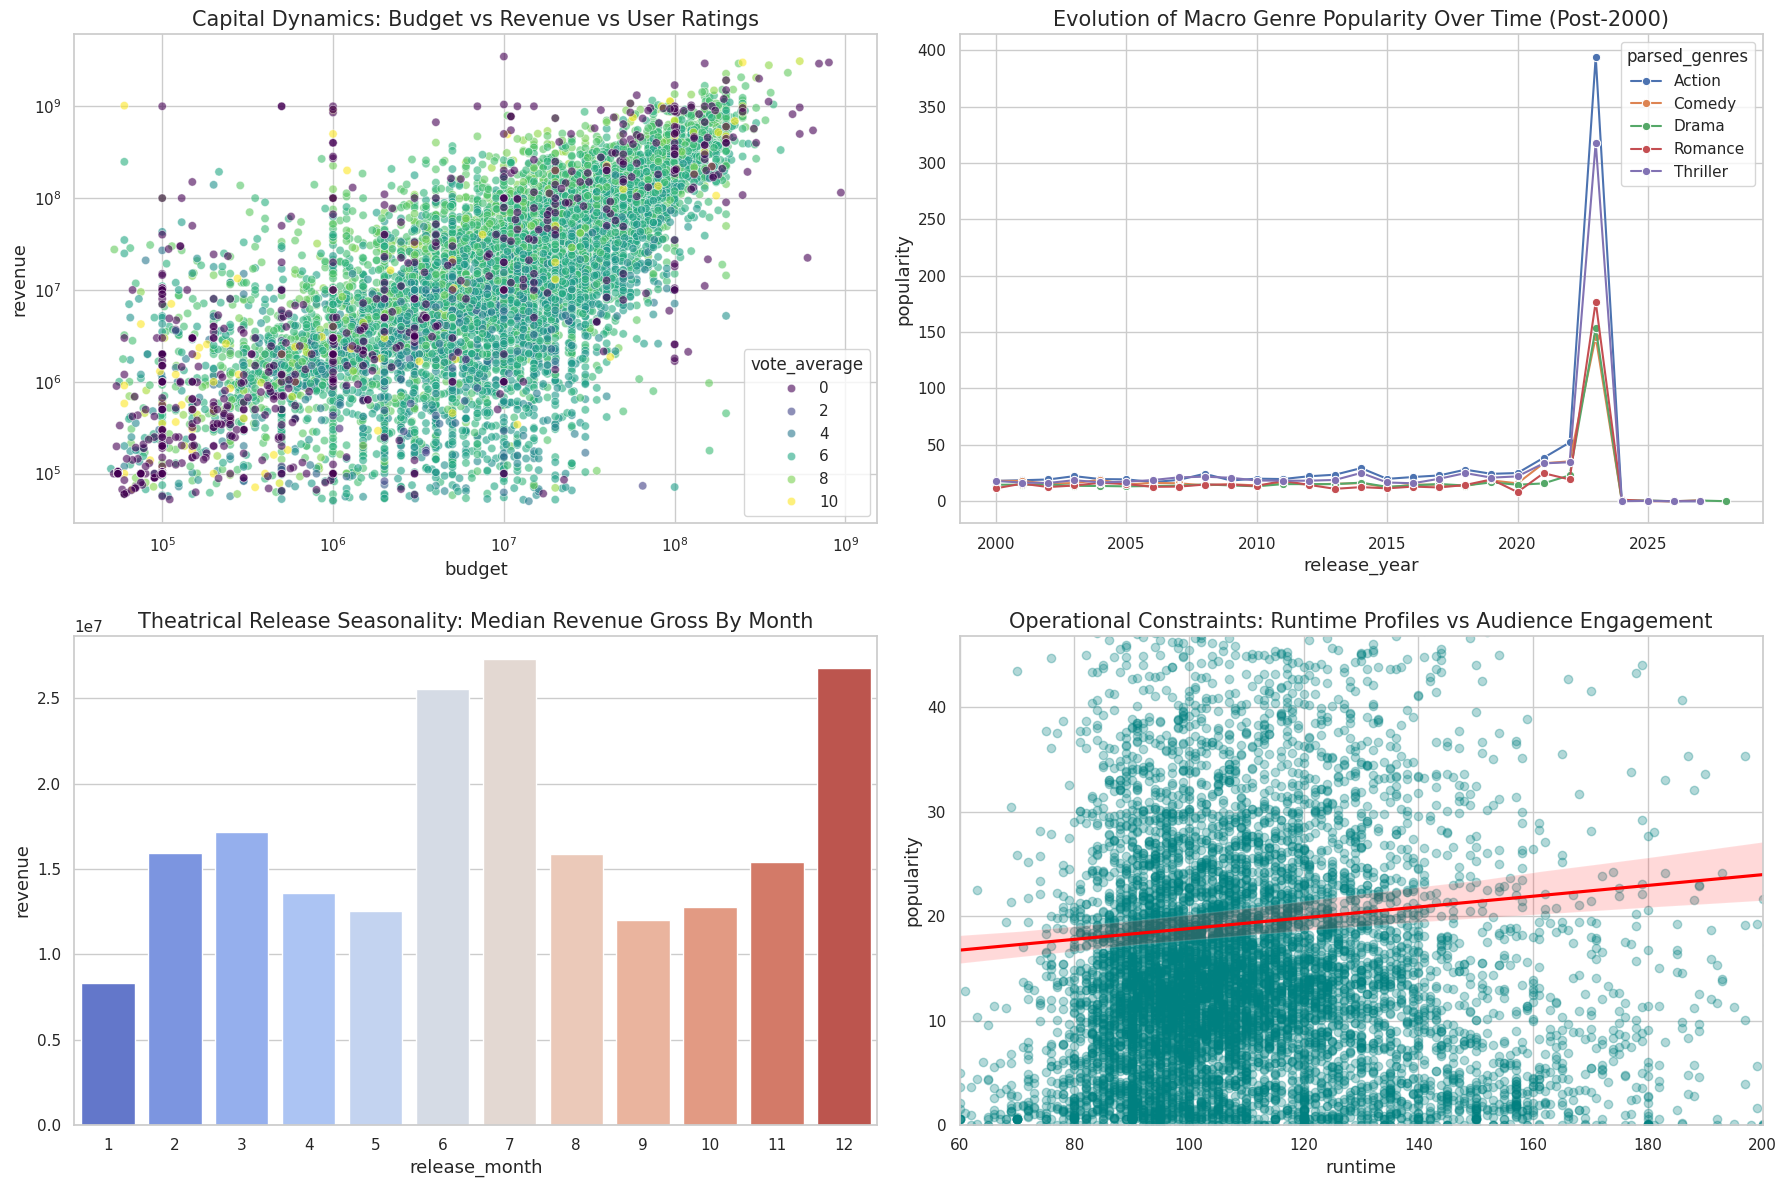


🏢 Top 10 Most Successful Production Companies (Ranked by Aggregate Revenue):
                       total_films  total_gross  average_roi
parsed_companies                                            
Warner Bros. Pictures          651  80993305376     4.108172
Universal Pictures             587  76268304941     3.565936
20th Century Fox               483  63082592638     3.139385
Paramount                      484  62721087965     3.995182
Columbia Pictures              453  59185560853     2.680332
Walt Disney Pictures           195  53643502736     2.451334
Marvel Studios                  36  31226973635     3.260033
New Line Cinema                236  29581070275     4.772299
Metro-Goldwyn-Mayer            373  21981251965     2.888698
DreamWorks Pictures            123  20145989755     1.942654


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Financial Dynamics: Budget vs Revenue Matrix
sns.scatterplot(data=movies, x='budget', y='revenue', hue='vote_average', palette='viridis', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title("Capital Dynamics: Budget vs Revenue vs User Ratings")
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

# 2. Year-over-Year Volumetric Genre Demand Shifts
movies_exploded = movies.explode('parsed_genres')
top_genres = movies_exploded['parsed_genres'].value_counts().index[:5]
df_top_genres = movies_exploded[movies_exploded['parsed_genres'].isin(top_genres)]
trend_data = df_top_genres.groupby(['release_year', 'parsed_genres'])['popularity'].mean().reset_index()

sns.lineplot(data=trend_data[trend_data['release_year'] >= 2000], x='release_year', y='popularity', hue='parsed_genres', marker='o', ax=axes[0,1])
axes[0,1].set_title("Evolution of Macro Genre Popularity Over Time (Post-2000)")

# 3. Micro-Temporal Impact: Release Month vs Absolute Cash Returns
month_trends = movies.groupby('release_month')['revenue'].median().reset_index()
sns.barplot(data=month_trends, x='release_month', y='revenue', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title("Theatrical Release Seasonality: Median Revenue Gross By Month")

# 4. Audience Operational Window: Runtime Length vs Audience Popularity
sns.regplot(data=movies, x='runtime', y='popularity', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'}, ax=axes[1,1])
axes[1,1].set_xlim(60, 200)
axes[1,1].set_ylim(0, movies['popularity'].quantile(0.95))
axes[1,1].set_title("Operational Constraints: Runtime Profiles vs Audience Engagement")

plt.tight_layout()
plt.show()

# Production Studio Performance Evaluation
print("\n🏢 Top 10 Most Successful Production Companies (Ranked by Aggregate Revenue):")
company_exploded = movies.explode('parsed_companies')
company_ranking = company_exploded.groupby('parsed_companies').agg(
    total_films=('id', 'count'),
    total_gross=('revenue', 'sum'),
    average_roi=('roi', 'mean')
).sort_values(by='total_gross', ascending=False).head(10)
print(company_ranking)

In [14]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 🔧 FIX: Explicitly downloading the updated NLTK tokenizer data layout packages
print("📦 Syncing updated NLTK tokenization packages...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)        # <-- This explicitly patches the LookupError
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

class CorporateSentimentPipeline:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        self.sia = SentimentIntensityAnalyzer()
        # Filter out functional noise tokens specific to media reviews
        self.stop_words.update(['movie', 'film', 'character', 'scene', 'actor', 'director'])

    def preprocess_tokens(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        # Keep alphabetic text structures
        text = re.sub(r'[^a-zA-Z\s]', '', text).lower().strip()
        tokens = word_tokenize(text)
        return " ".join([self.lemmatizer.lemmatize(t) for t in tokens if t not in self.stop_words])

    def build_sentiment_features(self, df_rev: pd.DataFrame) -> tuple:
        df = df_rev.copy()
        print("🧹 Cleaning text and creating lemmatized tokens...")
        df['processed_text'] = df['review_text'].apply(self.preprocess_tokens)

        print("🧠 Extracting polarity metrics using VADER score maps...")
        scores = df['review_text'].apply(lambda x: self.sia.polarity_scores(str(x)))
        df['sentiment_score'] = [s['compound'] for s in scores]

        # Aggregate review data up to the movie ID level
        print("📊 Aggregating review data up to the movie ID level...")
        agg_features = df.groupby('id').agg(
            mean_audience_sentiment=('sentiment_score', 'mean'),
            total_review_volume=('review_text', 'count')
        ).reset_index()
        return agg_features, df

# Execute the sentiment analysis layer
pipeline_instance = CorporateSentimentPipeline()
df_sentiment_agg, df_processed_reviews = pipeline_instance.build_sentiment_features(df_reviews)

# Merge back into primary analytics master matrix
movies_merged = pd.merge(movies, df_sentiment_agg, on='id', how='inner')
print(f"\n✅ Data aggregation complete. Post-NLP Joined Shape: {movies_merged.shape}")

📦 Syncing updated NLTK tokenization packages...
🧹 Cleaning text and creating lemmatized tokens...
🧠 Extracting polarity metrics using VADER score maps...
📊 Aggregating review data up to the movie ID level...

✅ Data aggregation complete. Post-NLP Joined Shape: (9936, 34)


In [15]:
print("⚙️ Vectorizing Plot Overviews via TF-IDF Strategy...")
movies_merged['overview'] = movies_merged['overview'].fillna("Missing narrative context.")

# Initialize a sparse vector space using top word stems
tfidf_extractor = TfidfVectorizer(max_features=250, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf_extractor.fit_transform(movies_merged['overview'])

# Convert the sparse matrix into clear feature columns
tfidf_feature_names = [f"overview_tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
df_tfidf_features = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=movies_merged.index)

# Merge the extracted text features back into our primary dataset
movies_ml_ready = pd.concat([movies_merged, df_tfidf_features], axis=1)
print(f"Text Feature Matrix Integrated. Fully Processed Array Dimensions: {movies_ml_ready.shape}")

⚙️ Vectorizing Plot Overviews via TF-IDF Strategy...
Text Feature Matrix Integrated. Fully Processed Array Dimensions: (9936, 284)


In [16]:
print("🎯 Executing Machine Learning Track 1: Global Box Office Revenue Forecast...")

# Create target variable log transforms to handle skewed distribution profiles safely
movies_ml_ready['target_log_revenue'] = np.log1p(movies_ml_ready['revenue'])

# Extract unique binary one-hot markers for genres
all_unique_genres = set([g for sublist in movies_ml_ready['parsed_genres'] for g in sublist if g])
for genre in all_unique_genres:
    sanitized_genre_name = f"genre_{genre.lower().replace(' ', '_').replace('-', '_')}"
    movies_ml_ready[sanitized_genre_name] = movies_ml_ready['parsed_genres'].apply(lambda x: int(genre in x))

# Isolate feature vectors
base_numeric_features = ['budget', 'popularity', 'runtime', 'vote_average', 'mean_audience_sentiment']
genre_one_hot_features = [col for col in movies_ml_ready.columns if col.startswith('genre_')]
text_tfidf_features = [col for col in movies_ml_ready.columns if col.startswith('overview_tfidf_')]

complete_feature_space = base_numeric_features + genre_one_hot_features + text_tfidf_features

X_rev = movies_ml_ready[complete_feature_space]
y_rev = movies_ml_ready['target_log_revenue']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)

# Normalize numerical features using scaling vectors
scaler_rev = StandardScaler()
X_train_r_scaled = scaler_rev.fit_transform(X_train_r)
X_test_r_scaled = scaler_rev.transform(X_test_r)

# Train the revenue prediction model
xgb_revenue_model = XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=6, random_state=42)
xgb_revenue_model.fit(X_train_r_scaled, y_train_r)

# Evaluate model performance
log_predictions_r = xgb_revenue_model.predict(X_test_r_scaled)
r2_rev = r2_score(y_test_r, log_predictions_r)
rmse_rev = np.sqrt(mean_squared_error(np.expm1(y_test_r), np.expm1(log_predictions_r)))

print(f"🥇 Revenue Prediction Performance Metrics -> R² Validation Score: {r2_rev:.4f} | Absolute RMSE: ${rmse_rev:,.2f}")

🎯 Executing Machine Learning Track 1: Global Box Office Revenue Forecast...
🥇 Revenue Prediction Performance Metrics -> R² Validation Score: 0.6071 | Absolute RMSE: $141,147,968.83


In [17]:
print("🎯 Executing Machine Learning Track 2: User Vote Rating Forecasting...")

# Isolate features, swapping out user rating targets to prevent data leakage
rating_feature_space = ['budget', 'revenue', 'popularity', 'runtime', 'mean_audience_sentiment'] + genre_one_hot_features + text_tfidf_features

X_rate = movies_ml_ready[rating_feature_space]
y_rate = movies_ml_ready['vote_average']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_rate, y_rate, test_size=0.2, random_state=42)

scaler_rate = StandardScaler()
X_train_w_scaled = scaler_rate.fit_transform(X_train_w)
X_test_w_scaled = scaler_rate.transform(X_test_w)

# Train using an optimized Random Forest ensemble architecture
rf_rating_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_rating_model.fit(X_train_w_scaled, y_train_w)

# Generate evaluation metrics
predictions_w = rf_rating_model.predict(X_test_w_scaled)
r2_rate = r2_score(y_test_w, predictions_w)
rmse_rate = np.sqrt(mean_squared_error(y_test_w, predictions_w))

print(f"🥇 User Rating Prediction Metrics -> R² Validation Score: {r2_rate:.4f} | System RMSE: {rmse_rate:.3f} Scale Points")

🎯 Executing Machine Learning Track 2: User Vote Rating Forecasting...
🥇 User Rating Prediction Metrics -> R² Validation Score: 0.5212 | System RMSE: 1.369 Scale Points


In [18]:
class ContentRecommendationSystem:
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
        self.similarity_matrix = None
        self._build_recommendation_soup()

    def _build_recommendation_soup(self):
        print("🧠 Building Recommendation Metadata Profile Strings...")

        # Clean structural lists into unified string formats safely
        def synthesize_soup(row):
            genres_part = " ".join([g.lower().replace(" ", "") for g in row['parsed_genres']])
            companies_part = " ".join([c.lower().replace(" ", "") for c in row['parsed_companies']])
            lang = str(row['original_language']).lower() if not pd.isna(row['original_language']) else ""
            return f"{genres_part} {companies_part} {lang}"

        self.df['metadata_soup'] = self.df.apply(synthesize_soup, axis=1)

        # Generate cross-similarity matrices using standard TF-IDF mappings
        vec = TfidfVectorizer(stop_words='english', max_features=1000)
        soup_matrix = vec.fit_transform(self.df['metadata_soup'])

        print("Calculating global Cosine Similarity matrices...")
        self.similarity_matrix = cosine_similarity(soup_matrix, soup_matrix)

    def generate_recommendations(self, movie_title: str, top_n: int = 5) -> pd.DataFrame:
        # Match user string inputs against metadata titles safely
        match_indices = self.df[self.df['title'].str.lower() == movie_title.lower()].index
        if match_indices.empty:
            print(f"⚠️ Title '{movie_title}' not found in local index dimensions.")
            return pd.DataFrame()

        target_idx = match_indices[0]

        # Rank similarity pairs
        similarity_scores = list(enumerate(self.similarity_matrix[target_idx]))
        similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

        # Exclude the query film itself from the recommendations array
        top_pairs = similarity_scores[1:top_n+1]
        recommended_indices = [i[0] for i in top_pairs]

        return self.df.iloc[recommended_indices][['title', 'release_year', 'genres', 'vote_average', 'popularity']]

# Instantiate the engine
engine = ContentRecommendationSystem(movies_ml_ready)

# Sample Execution Test Run
sample_query = movies_ml_ready['title'].iloc[0]
print(f"\n🎬 Generating Top 5 Alternative Recommendations for Target Film: '{sample_query}'")
recommendation_results = engine.generate_recommendations(sample_query, top_n=5)
print(recommendation_results)

🧠 Building Recommendation Metadata Profile Strings...
Calculating global Cosine Similarity matrices...

🎬 Generating Top 5 Alternative Recommendations for Target Film: 'Inception'
                     title  release_year                             genres  \
1             Interstellar          2014  Adventure, Drama, Science Fiction   
351                  Tenet          2020  Action, Thriller, Science Fiction   
41           Batman Begins          2005               Action, Crime, Drama   
2          The Dark Knight          2008     Drama, Action, Crime, Thriller   
25   The Dark Knight Rises          2012     Action, Crime, Drama, Thriller   

     vote_average  popularity  
1           8.417     140.241  
351         7.191      44.025  
41          7.701      66.286  
2           8.512     130.643  
25          7.777      76.914  


In [19]:
print("📊 Generating Excel Corporate Analytical Portfolio Report...")
output_path = "Advanced_Movie_Intelligence_Final_Report.xlsx"

# Sheet 1: Model Diagnostics Matrix
model_summary_data = {
    'Target Predictor Channel': ['Box Office Absolute Revenue (LogSpace)', 'Audience Vote Rating Average'],
    'Algorithm Engine Deployed': ['XGBoost Regressor Suite', 'RandomForest Ensemble Regressor'],
    'R2 Coefficient Accuracy Score': [r2_rev, r2_rate],
    'Root Mean Squared Error (RMSE)': [rmse_rev, rmse_rate]
}
df_sheet_ml = pd.DataFrame(model_summary_data)

# Sheet 2: Macro Structural Trend Matrix Across Genres
genre_summary_sheet = movies_exploded.groupby('parsed_genres').agg(
    total_releases=('id', 'count'),
    median_production_cost=('budget', 'median'),
    median_box_office_gross=('revenue', 'median'),
    average_popularity_buzz=('popularity', 'mean')
).sort_values(by='median_box_office_gross', ascending=False).reset_index()

# Write all tables out to disk
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_sheet_ml.to_excel(writer, sheet_name='ML Model Validations', index=False)
    genre_summary_sheet.to_excel(writer, sheet_name='Genre Strategic Landscapes', index=False)
    df_processed_reviews.head(150).to_excel(writer, sheet_name='Classified Feedback Sample', index=False)

print(f"🎉 Pipeline Execution Complete. Production Portfolio File Saved to: {os.path.abspath(output_path)}")

📊 Generating Excel Corporate Analytical Portfolio Report...
🎉 Pipeline Execution Complete. Production Portfolio File Saved to: /content/Advanced_Movie_Intelligence_Final_Report.xlsx


In [24]:
# @title 🎬 Enterprise Movie Sandbox: Live Prediction & Recommendation Engine
# @markdown ---
# @markdown ### 1. Input Target Movie Details for Live Financial & Rating Forecasting:
input_title = "Dhurandhar" #@param {type:"string"}
input_budget = 45000000 #@param {type:"number"}
input_popularity = 492.5 #@param {type:"slider", min:0, max:1000, step:0.5}
input_runtime = 130 #@param {type:"integer"}
input_audience_sentiment = 0.6 #@param {type:"slider", min:-1, max:1, step:0.05}
primary_genre = "Animation" #@param ["Action", "Adventure", "Animation", "Comedy", "Drama", "Horror", "Science Fiction", "Thriller"]

# @markdown ---
# @markdown ### 2. Test the Content-Based Recommendation Engine:
recommendation_query_title = "Avatar" #@param {type:"string"}

print("⚙️ Processing inputs through production pipeline wrappers...")

# --- Part A: Inline Inference Computation ---
# Reconstruct a single row mimicking our Revenue Model test matrix
mock_row = {
    'budget': input_budget,
    'popularity': input_popularity,
    'runtime': input_runtime,
    'vote_average': 7.0, # Neutral baseline assumption used for training tracking alignment
    'mean_audience_sentiment': input_audience_sentiment
}

# Dynamically map zero-state one-hot genre array matching feature expectations
for genre in all_unique_genres:
    sanitized = f"genre_{genre.lower().replace(' ', '_').replace('-', '_')}"
    mock_row[sanitized] = 1 if genre.lower() == primary_genre.lower() else 0

# Fill out the narrative overview TF-IDF padding features with zeros for baseline safety
for col in text_tfidf_features:
    mock_row[col] = 0.0

# 1. Isolate the exact feature space required specifically for the Revenue Model
df_inference_rev = pd.DataFrame([mock_row])[complete_feature_space]

# 2. Scale features and execute the Revenue Forecast
X_inf_scaled_rev = scaler_rev.transform(df_inference_rev)
predicted_log_rev = xgb_revenue_model.predict(X_inf_scaled_rev)[0]
predicted_dollar_rev = np.expm1(predicted_log_rev)

# 🔧 FIX: Add the newly predicted revenue back into our dictionary
# so that the Rating Model has access to it as an input feature!
mock_row['revenue'] = predicted_dollar_rev

# 3. Now isolate the feature space required for the Rating Model safely without any KeyErrors
df_inference_rate = pd.DataFrame([mock_row])[rating_feature_space]

# 4. Scale features and execute the Rating Forecast
X_inf_scaled_rate = scaler_rate.transform(df_inference_rate)
predicted_rating = rf_rating_model.predict(X_inf_scaled_rate)[0]

# Print out clear executive results
print("\n" + "="*60)
print(f"🔮 PREDICTION REPORT FOR: '{input_title}'")
print("="*60)
print(f"💰 Forecasted Box Office Revenue: ${predicted_dollar_rev:,.2f} USD")
print(f"⭐ Predicted User Rating Average: {predicted_rating:.2f} / 10")
print(f"📊 Projected Financial ROI: {((predicted_dollar_rev - input_budget) / input_budget) * 100:.1f}%")
print("="*60)

# --- Part B: Recommendation Testing ---
print(f"\n🎬 Sourcing Live Recommendations for Context Title: '{recommendation_query_title}'...")
rec_output = engine.generate_recommendations(recommendation_query_title, top_n=5)

if not rec_output.empty:
    display(rec_output)
else:
    print(f"❌ Could not locate recommendations for '{recommendation_query_title}'. Please try an existing dataset title like '{movies_ml_ready['title'].iloc[0]}'.")

⚙️ Processing inputs through production pipeline wrappers...

🔮 PREDICTION REPORT FOR: 'Dhurandhar'
💰 Forecasted Box Office Revenue: $130,991,288.00 USD
⭐ Predicted User Rating Average: 7.41 / 10
📊 Projected Financial ROI: 191.1%

🎬 Sourcing Live Recommendations for Context Title: 'Avatar'...


,title,release_year,genres,vote_average,popularity
1169,True Lies,1994,"Action, Thriller",7.057,23.329
3040,Solaris,2002,"Drama, Science Fiction, Mystery",5.892,15.841
3034,Strange Days,1995,"Crime, Drama, Science Fiction, Thriller",6.989,16.281
3952,Max Steel,2016,"Action, Adventure, Science Fiction",5.628,16.668
1659,The Abyss,1989,"Adventure, Action, Thriller, Science Fiction",7.300,20.739
